In [42]:
import pandas as pd
import numpy as np
import joblib
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [43]:
df = pd.read_csv("../data/data.csv", sep=";")

# Remove spaces/tabs at the beginning/end of column names
df.columns = df.columns.str.strip()

print("Dataset shape:", df.shape)

Dataset shape: (4424, 37)


In [44]:
df["Risk"] = df["Target"].map({
    "Dropout": 1,
    "Enrolled": 0,
    "Graduate": 0
})

print(df["Risk"].value_counts())

Risk
0    3003
1    1421
Name: count, dtype: int64


In [45]:
early_features = [
    "Marital status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Previous qualification (grade)",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Admission grade",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "Age at enrollment",
    "International",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

X = df[early_features]
y = df["Risk"]

print("X:", X.shape)
print("y:", y.shape)

X: (4424, 24)
y: (4424,)


In [46]:
numerical_features = [
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

In [47]:
categorical_features = [
    "Marital status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (3539, 24)
X_test : (885, 24)


In [49]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessor created!")

Preprocessor created!


In [50]:
final_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                C=10,
                solver="liblinear",
                class_weight="balanced",
                max_iter=3000
            )
        )
    ]
)

print("Final tuned model created!")

Final tuned model created!


In [51]:
final_model.fit(X_train, y_train)

print("Final tuned model trained successfully!")

Final tuned model trained successfully!


In [52]:
y_pred = final_model.predict(X_test)

y_prob = final_model.predict_proba(X_test)[:, 1]

print("First 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 dropout probabilities:")
print(y_prob[:10])

First 10 predictions:
[0 0 1 0 0 0 1 0 0 1]

First 10 dropout probabilities:
[0.0771431  0.35773937 0.67771494 0.18737372 0.18498839 0.09964156
 0.55700022 0.46828637 0.17528354 0.92348996]


In [53]:
# Select representative training students
background_raw = X_train.sample(
    n=min(200, len(X_train)),
    random_state=42
)

# Transform them using the EXACT same preprocessing
background_transformed = final_model.named_steps[
    "preprocessor"
].transform(background_raw)

print(
    "SHAP background shape:",
    background_transformed.shape
)

SHAP background shape: (200, 238)


In [54]:
joblib.dump(
    background_transformed,
    "../models/shap_background.pkl"
)

print("SHAP background saved successfully!")

SHAP background saved successfully!


In [55]:
model = final_model.named_steps["model"]

explainer = shap.LinearExplainer(
    model,
    background_transformed
)

print("SHAP explainer created successfully!")

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


SHAP explainer created successfully!


In [56]:
X_test_transformed = final_model.named_steps[
    "preprocessor"
].transform(X_test)

In [57]:
shap_values = explainer(
    X_test_transformed
)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


In [58]:
feature_names = final_model.named_steps[
    "preprocessor"
].get_feature_names_out()

print(
    "Number of transformed features:",
    len(feature_names)
)

Number of transformed features: 238


In [59]:
if hasattr(X_test_transformed, "toarray"):
    test_data_for_shap = X_test_transformed.toarray()
else:
    test_data_for_shap = X_test_transformed

shap_explanation = shap.Explanation(
    values=shap_values.values,
    base_values=shap_values.base_values,
    data=test_data_for_shap,
    feature_names=feature_names
)

print("Named SHAP explanation created!")

Named SHAP explanation created!


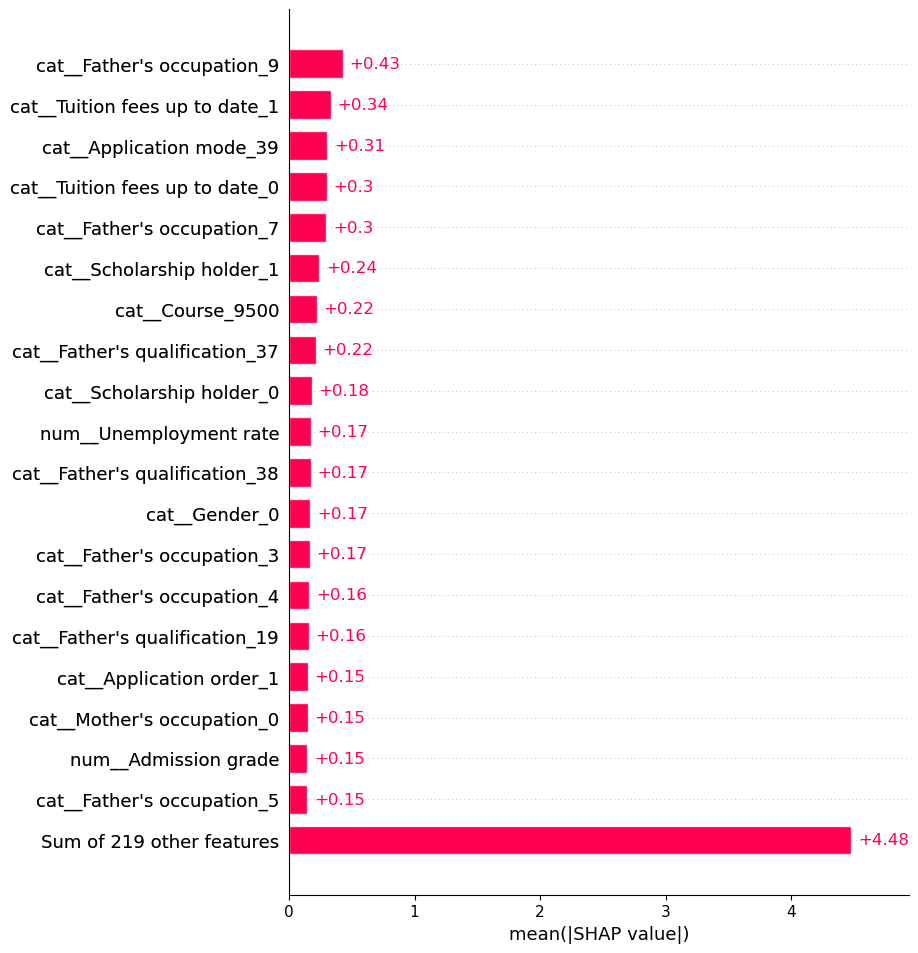

In [60]:
shap.plots.bar(
    shap_explanation,
    max_display=20
)

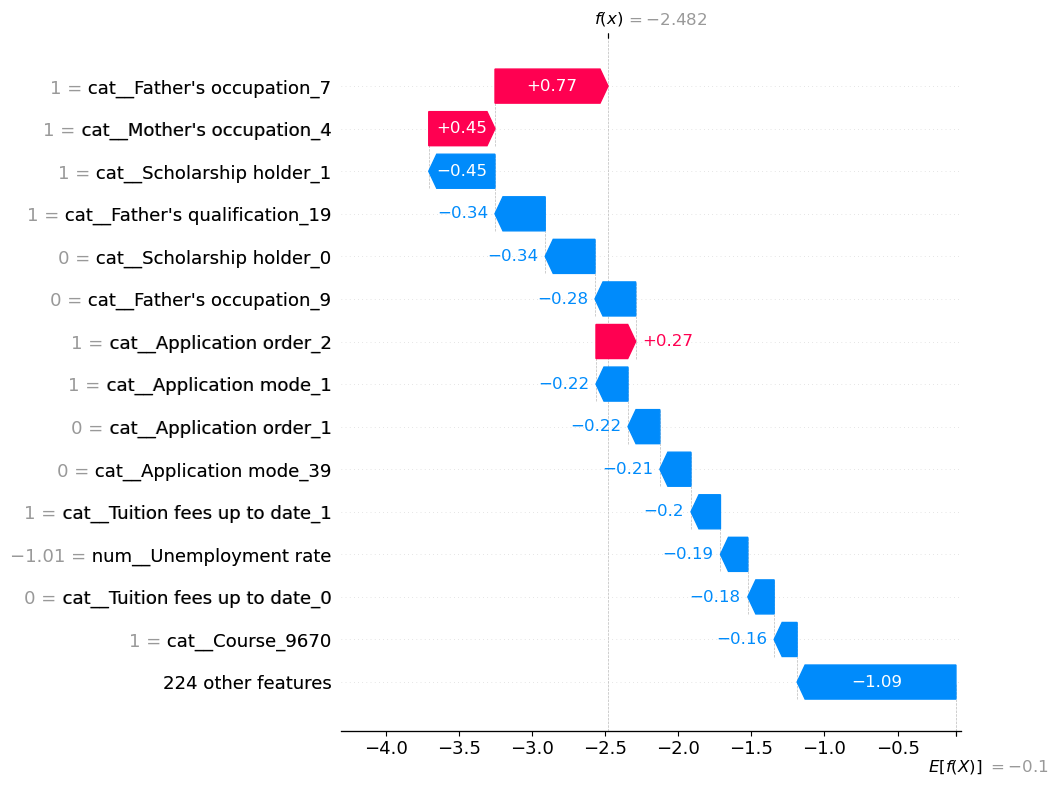

In [61]:
student_index = 0

shap.plots.waterfall(
    shap_explanation[student_index],
    max_display=15
)

In [62]:
student = X_test.iloc[[student_index]]

dropout_probability = final_model.predict_proba(
    student
)[0, 1]

print(
    "Student index:",
    student_index
)

print(
    "Dropout probability:",
    round(
        dropout_probability * 100,
        2
    ),
    "%"
)

Student index: 0
Dropout probability: 7.71 %
